In [1]:
%load_ext autoreload
%autoreload 2
# load some base packages
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import numpy as np
import astropy.units as u
import astropy.constants as const
from astropy.cosmology import FlatLambdaCDM

# load in the stacking package
sys.path.insert(0, '/home/finneas/Documents/COMAP/stacking')
import lim_stacker as st

In [73]:
# This stack is a test on the BGS map / cat generated in the other notebook to make sure it works, using mostly the same params as LAEs.

#os.chdir('/home/finneas/Documents/COMAP/stacking/stacks_hetdex/')

# list of the paths to each map file
# (note they're in a weird order due to a defunct naming convention -- Field 1
#  is co2S, Field 2 is co7, and Field 3 is co6)
mapfiles = ['/home/finneas/Documents/COMAP/Low Redshift search/fiuducial_schechter_mags_mass_map.npz',
            '/home/finneas/Documents/COMAP/for_finneas/comap_data/co6_s12_v5_take6_n5_subtr_exper.h5',
            '/home/finneas/Documents/COMAP/for_finneas/comap_data/co7_s12_v5_take6_n5_subtr_exper.h5'][0]

# path to the catalog file
# needs to be a zipped numpy file with keys 'ra', 'dec', and 'z'
#catfiles = '/home/finneas/Documents/COMAP/for_finneas/catalogs/QSO_cat_iron_cumulative_v0.npz'
catfiles = '/home/finneas/Documents/COMAP/Low Redshift search/fiuducial_schechter_mags_cat.npz'

# load the parameters into a custom python object. this empty function
# call will load the default parameters, which should all be good. To explore what
# the defaults are, check out 'param_defaults.py'
params = st.parameters()

### messsing with parameters
#params.goalnumcutouts = [5,0,5]
params.parallelize = True


params.chanwidth = 0.03125 #***
params.chanmeanfilter = False
params.lowmodefilter = False
params.rotate = True

#params.plotspace = False
#params.plotfreq = False
#params.plotcubelet = False
params.returncutlist = False
params.usefeed = False
params.physicalspace = False

#params.freqstackwidth = 4
#params.spacestackwidth = 2
params.xwidth = 5
params.ywidth = 5

###

# set up where you'd like the stack results to be output to
params.savepath = 'BGS_test'
params.make_output_pathnames()

mapinst, catinst = st.field_setup(mapfiles, catfiles, params, sim_cat=True, lcat_cutoff=8260913427, goal_nobj=1000, weight='linear') 



	1000 halos remain after observability cuts
trimming catalog


In [74]:
catinst.nobj

1000

   done 0 of 1000 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1874: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1875: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))


   done 100 of 1000 cutouts in this field
   done 200 of 1000 cutouts in this field
   done 300 of 1000 cutouts in this field
   done 400 of 1000 cutouts in this field
   done 500 of 1000 cutouts in this field
   done 600 of 1000 cutouts in this field
   done 700 of 1000 cutouts in this field
   done 800 of 1000 cutouts in this field
   done 900 of 1000 cutouts in this field
(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:865: OptimizeWarning: Covariance of the parameters could not be estimated
  fitopt, fitcov = curve_fit(gauss, bincents, counts, p0=[2000,0,2])


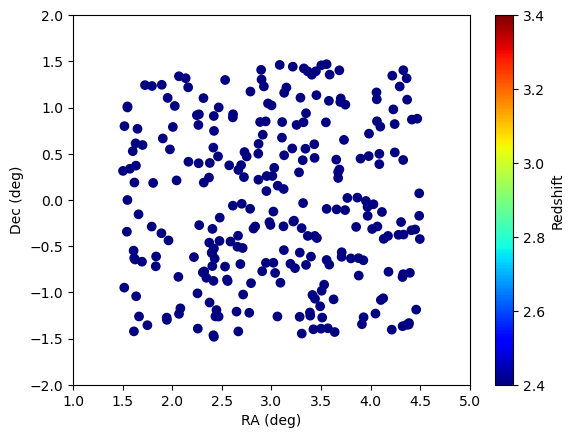

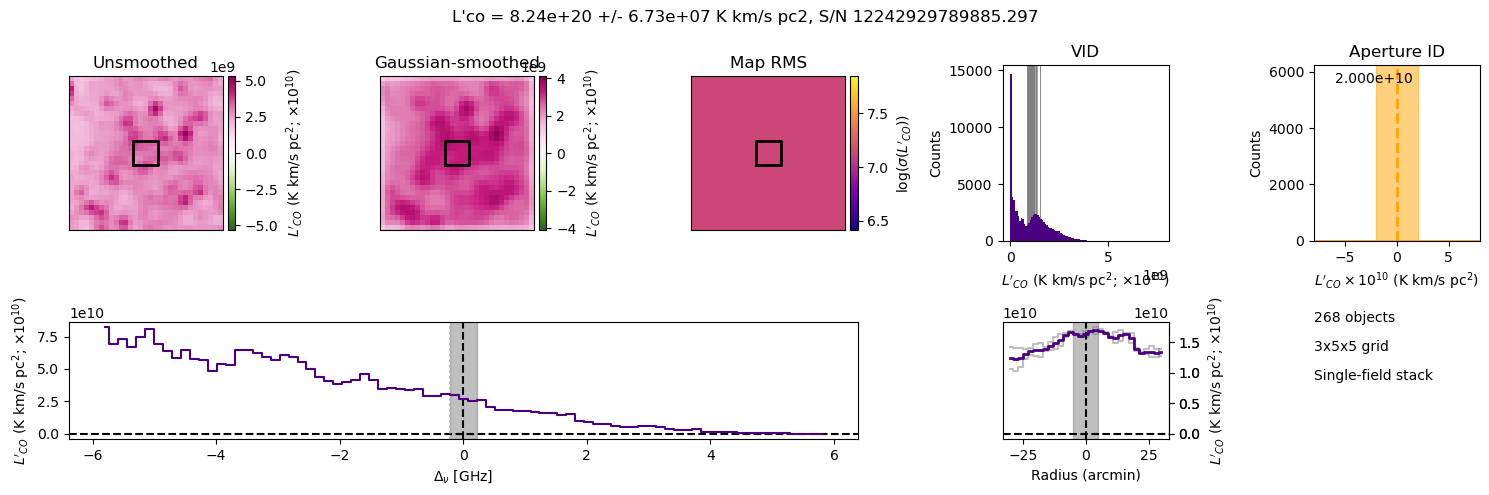

In [75]:
# load in and set up the maps and catalog
params.centfreq = 100.1;
#maplist, catlist = st.setup(mapfiles, catfiles, params)
stackcube = st.field_stack(mapinst, catinst, params)

In [69]:
catinst.observation_cull(params, 10000, 1000)


	1000 halos remain after observability cuts


In [70]:
len(catinst.Lcat)

1000

In [71]:
st.minmax(mapinst.ra)

array([1.        , 4.96666667])

In [67]:
# load in and set up the maps and catalog
params.centfreq = 100.2;
maplist, catlist = st.setup(mapfiles, catfiles, params)
stackcube = st.stacker(maplist, catlist, params)

AttributeError: 'maps' object has no attribute 'fieldcent'

In [4]:
# load in and set up the maps and catalog
freq_offset = 1100;

for freq in [100, 100.1, 100.2, 100.3, 100.4, 100.5, 100.6, 100.7, 100.8, 100.9, 101.0]:
    print(f'######## STACKING AT FREQUENCY: {freq} #########')
    params.centfreq = freq;
    
    maplist, catlist = st.setup(mapfiles, catfiles, params)
            
    # offset the catalog by 200 km/s
    for catinst in catlist:
        print(f"offsetting by {freq_offset}")
        dz = -freq_offset*u.km/u.s / (const.c.to(u.km/u.s)) * (1+catinst.z) # this is following steidel+2018, equation 5
        newz = dz.value + catinst.z
        catinst.z = newz
    
    stackcube = st.stacker(maplist, catlist, params )

######## STACKING AT FREQUENCY: 100 #########
scaling rms
masking isolated signal pixels
trimming catalog


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:2040: RuntimeWarning: Mean of empty slice
  goodidx = np.where(~np.isnan(np.nanmean(mapinst.map, axis=0)))


scaling rms
masking isolated signal pixels
trimming catalog
scaling rms
masking isolated signal pixels
trimming catalog
offsetting by 1100
offsetting by 1100
offsetting by 1100
Starting field 1
Starting a process with 0 catalog objects
No values to stack in this fieldStarting a process with 0 catalog objects

Starting a process with 0 catalog objects
No values to stack in this fieldStarting a process with 0 catalog objects
No values to stack in this field

No values to stack in this field
Starting a process with 0 catalog objects
No values to stack in this field
Starting field 2
Starting a process with 0 catalog objects
No values to stack in this fieldStarting a process with 0 catalog objects

No values to stack in this fieldStarting a process with 0 catalog objects

No values to stack in this fieldStarting a process with 0 catalog objects

No values to stack in this field
Starting a process with 0 catalog objects
No values to stack in this field
Starting field 3
Starting a process wit

AttributeError: 'NoneType' object has no attribute 'stackin_cubelet'

scaling rms
masking isolated signal pixels
trimming catalog
scaling rms
masking isolated signal pixels


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:2040: RuntimeWarning: Mean of empty slice
  goodidx = np.where(~np.isnan(np.nanmean(mapinst.map, axis=0)))


trimming catalog
scaling rms
masking isolated signal pixels
trimming catalog
Starting field 1
Starting a process with 1477 catalog objects
Starting a process with 1477 catalog objects
   done 0 of 1477 cutouts in this fieldStarting a process with 1477 catalog objects

Starting a process with 1477 catalog objects
Starting a process with 1477 catalog objects
   done 0 of 1477 cutouts in this field
   done 0 of 1477 cutouts in this field
   done 0 of 1477 cutouts in this field
   done 0 of 1477 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tool

   done 100 of 1477 cutouts in this field
   done 100 of 1477 cutouts in this field
   done 100 of 1477 cutouts in this field
   done 100 of 1477 cutouts in this field
   done 100 of 1477 cutouts in this field
   done 200 of 1477 cutouts in this field
   done 200 of 1477 cutouts in this field
   done 200 of 1477 cutouts in this field
   done 200 of 1477 cutouts in this field
   done 200 of 1477 cutouts in this field
   done 300 of 1477 cutouts in this field
   done 300 of 1477 cutouts in this field
   done 400 of 1477 cutouts in this field
   done 300 of 1477 cutouts in this field
   done 300 of 1477 cutouts in this field
   done 400 of 1477 cutouts in this field
   done 400 of 1477 cutouts in this field
   done 300 of 1477 cutouts in this field
   done 500 of 1477 cutouts in this field
   done 400 of 1477 cutouts in this field
   done 500 of 1477 cutouts in this field
   done 600 of 1477 cutouts in this field
   done 500 of 1477 cutouts in this field
   done 400 of 1477 cutouts in thi

...

(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
   done 1800 of 1822 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1292: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
Field 3 complete


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1197: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(maplist[i].rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


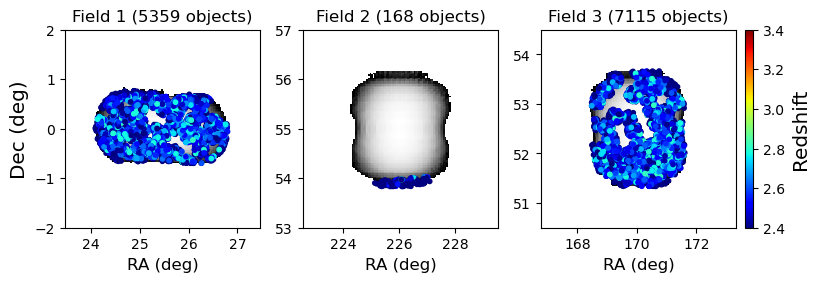

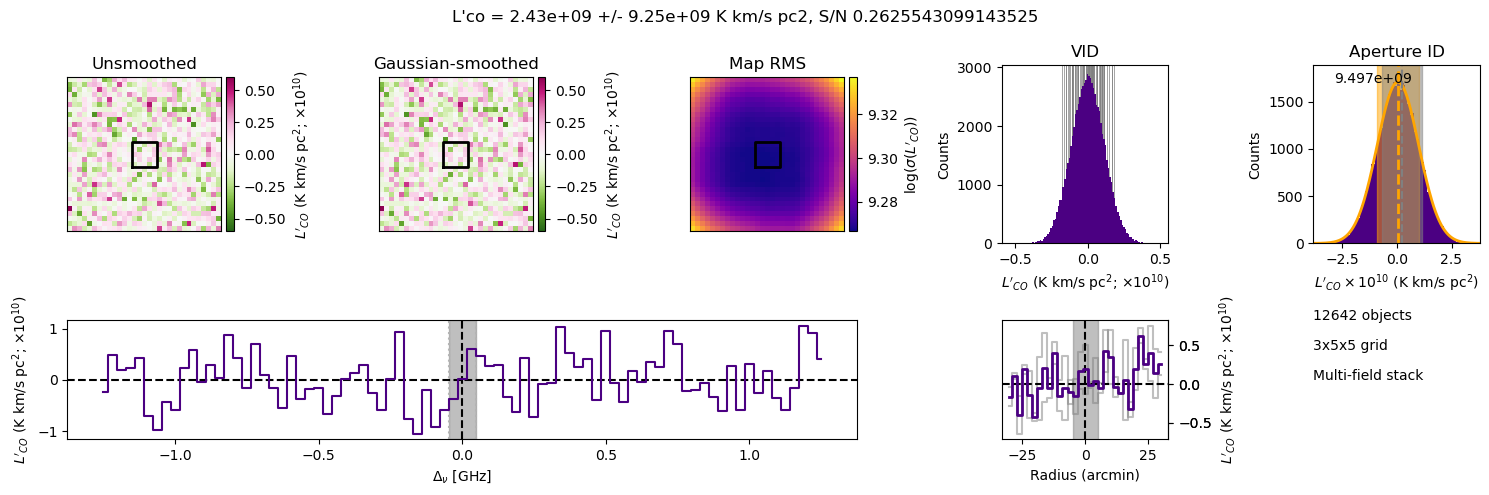

In [38]:
# load in and set up the maps and catalog
params.centfreq = 100.3;
maplist, catlist = st.setup(mapfiles, catfiles, params)
stackcube = st.stacker(maplist, catlist, params)

scaling rms
masking isolated signal pixels
trimming catalog
scaling rms
masking isolated signal pixels


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:2040: RuntimeWarning: Mean of empty slice
  goodidx = np.where(~np.isnan(np.nanmean(mapinst.map, axis=0)))


trimming catalog
scaling rms
masking isolated signal pixels
trimming catalog
Starting field 1
Starting a process with 1467 catalog objectsStarting a process with 1467 catalog objects

Starting a process with 1467 catalog objects   done 0 of 1467 cutouts in this field

Starting a process with 1467 catalog objects
Starting a process with 1469 catalog objects
   done 0 of 1469 cutouts in this field
   done 0 of 1467 cutouts in this field
   done 0 of 1467 cutouts in this field
   done 0 of 1467 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tool

   done 100 of 1469 cutouts in this field
   done 100 of 1467 cutouts in this field
   done 100 of 1467 cutouts in this field
   done 100 of 1467 cutouts in this field
   done 100 of 1467 cutouts in this field
   done 200 of 1469 cutouts in this field
   done 200 of 1467 cutouts in this field
   done 200 of 1467 cutouts in this field
   done 200 of 1467 cutouts in this field
   done 300 of 1469 cutouts in this field
   done 200 of 1467 cutouts in this field
   done 300 of 1467 cutouts in this field
   done 400 of 1469 cutouts in this field
   done 300 of 1467 cutouts in this field
   done 300 of 1467 cutouts in this field
   done 400 of 1467 cutouts in this field
   done 400 of 1467 cutouts in this field
   done 300 of 1467 cutouts in this field
   done 500 of 1469 cutouts in this field
   done 400 of 1467 cutouts in this field
   done 600 of 1469 cutouts in this field
   done 500 of 1467 cutouts in this field
   done 500 of 1467 cutouts in this field
   done 400 of 1467 cutouts in thi

...

(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
   done 1800 of 1814 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1292: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
Field 3 complete


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1197: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(maplist[i].rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


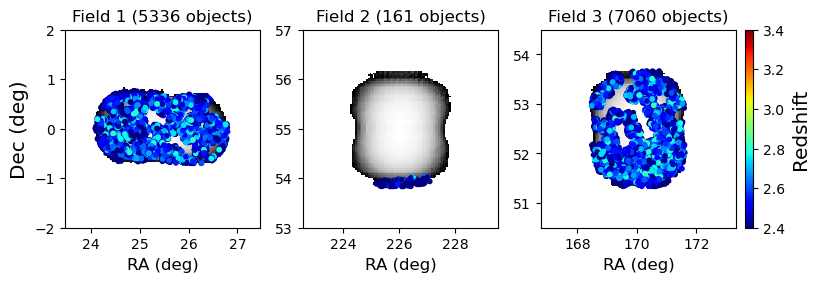

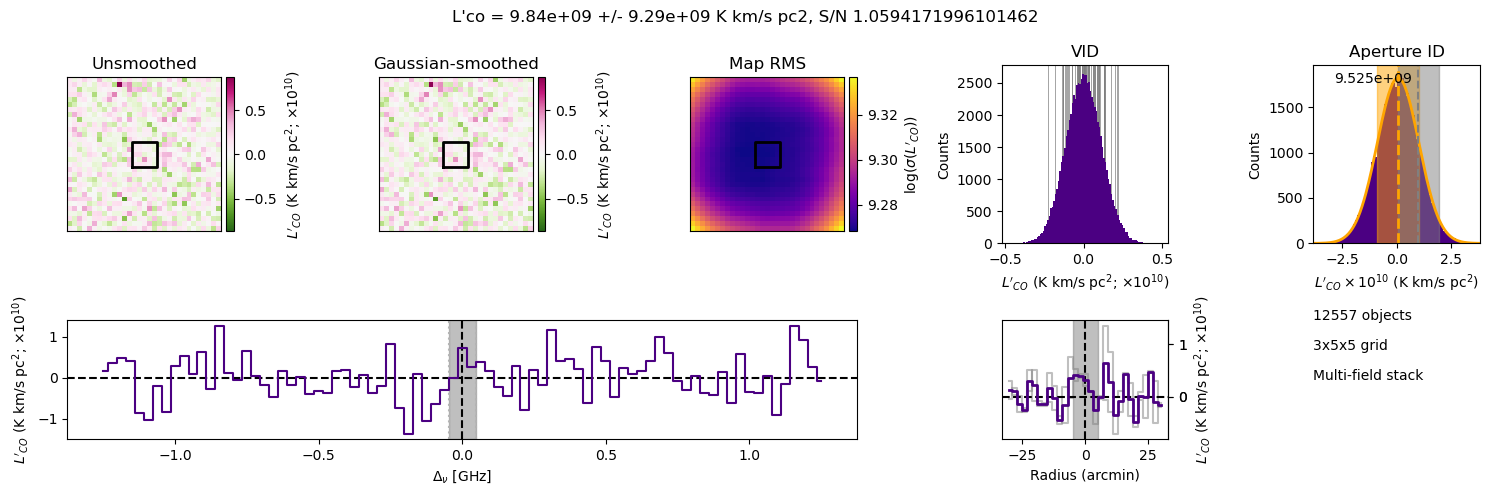

In [39]:
# load in and set up the maps and catalog
params.centfreq = 100.4;
maplist, catlist = st.setup(mapfiles, catfiles, params)
stackcube = st.stacker(maplist, catlist, params)

scaling rms
masking isolated signal pixels
trimming catalog
scaling rms
masking isolated signal pixels


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:2040: RuntimeWarning: Mean of empty slice
  goodidx = np.where(~np.isnan(np.nanmean(mapinst.map, axis=0)))


trimming catalog
scaling rms
masking isolated signal pixels
trimming catalog
Starting field 1
Starting a process with 1465 catalog objects
Starting a process with 1465 catalog objects
Starting a process with 1465 catalog objects
   done 0 of 1465 cutouts in this fieldStarting a process with 1465 catalog objects

Starting a process with 1465 catalog objects
   done 0 of 1465 cutouts in this field
   done 0 of 1465 cutouts in this field
   done 0 of 1465 cutouts in this field
   done 0 of 1465 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tool

   done 100 of 1465 cutouts in this field
   done 100 of 1465 cutouts in this field
   done 100 of 1465 cutouts in this field
   done 100 of 1465 cutouts in this field
   done 100 of 1465 cutouts in this field
   done 200 of 1465 cutouts in this field
   done 200 of 1465 cutouts in this field
   done 200 of 1465 cutouts in this field
   done 200 of 1465 cutouts in this field
   done 300 of 1465 cutouts in this field
   done 200 of 1465 cutouts in this field
   done 300 of 1465 cutouts in this field
   done 400 of 1465 cutouts in this field
   done 300 of 1465 cutouts in this field
   done 300 of 1465 cutouts in this field
   done 400 of 1465 cutouts in this field
   done 300 of 1465 cutouts in this field
   done 400 of 1465 cutouts in this field
   done 500 of 1465 cutouts in this field
   done 400 of 1465 cutouts in this field
   done 600 of 1465 cutouts in this field
   done 500 of 1465 cutouts in this field
   done 400 of 1465 cutouts in this field
   done 500 of 1465 cutouts in thi

...

(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
   done 1800 of 1805 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1292: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
Field 3 complete


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1197: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(maplist[i].rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


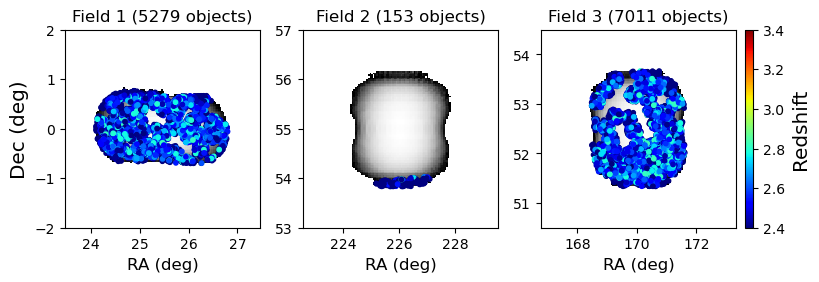

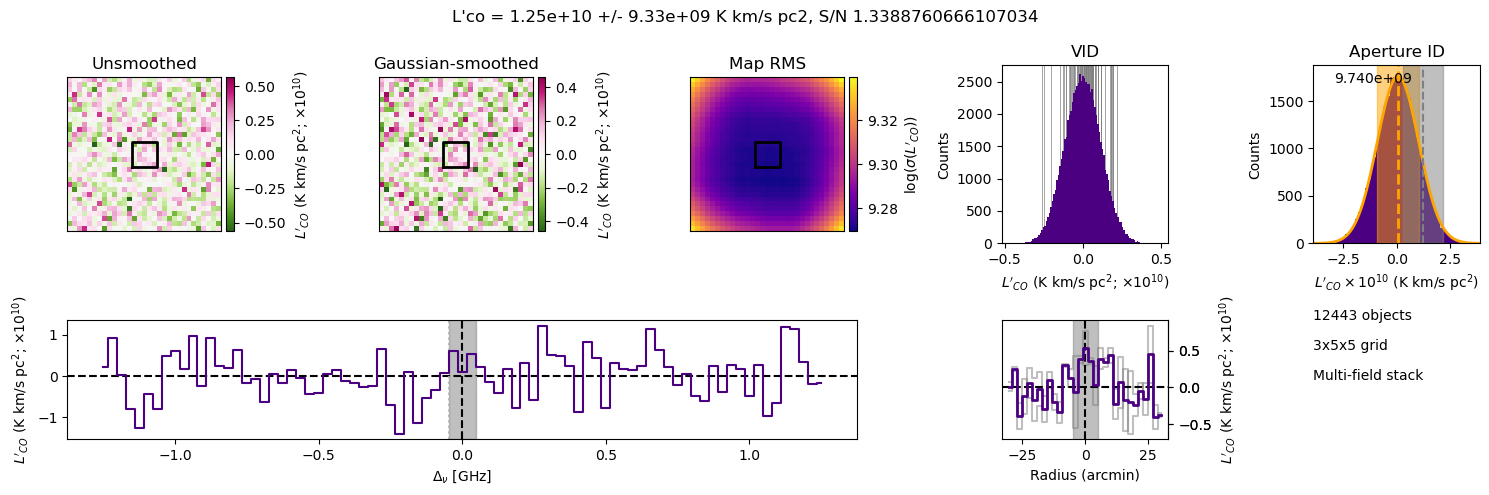

In [40]:
# load in and set up the maps and catalog
params.centfreq = 100.5;
maplist, catlist = st.setup(mapfiles, catfiles, params)
stackcube = st.stacker(maplist, catlist, params)

scaling rms
masking isolated signal pixels
trimming catalog
scaling rms
masking isolated signal pixels


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:2040: RuntimeWarning: Mean of empty slice
  goodidx = np.where(~np.isnan(np.nanmean(mapinst.map, axis=0)))


trimming catalog
scaling rms
masking isolated signal pixels
trimming catalog
Starting field 1
Starting a process with 1459 catalog objects
Starting a process with 1459 catalog objects
   done 0 of 1459 cutouts in this fieldStarting a process with 1459 catalog objects

Starting a process with 1459 catalog objects   done 0 of 1459 cutouts in this field

Starting a process with 1461 catalog objects
   done 0 of 1459 cutouts in this field
   done 0 of 1459 cutouts in this field
   done 0 of 1461 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tool

   done 100 of 1459 cutouts in this field
   done 100 of 1461 cutouts in this field
   done 100 of 1459 cutouts in this field
   done 100 of 1459 cutouts in this field
   done 100 of 1459 cutouts in this field
   done 200 of 1459 cutouts in this field
   done 200 of 1459 cutouts in this field
   done 200 of 1461 cutouts in this field
   done 200 of 1459 cutouts in this field
   done 200 of 1459 cutouts in this field
   done 300 of 1461 cutouts in this field
   done 300 of 1459 cutouts in this field
   done 300 of 1459 cutouts in this field
   done 400 of 1461 cutouts in this field
   done 300 of 1459 cutouts in this field
   done 300 of 1459 cutouts in this field
   done 400 of 1459 cutouts in this field
   done 400 of 1459 cutouts in this field
   done 500 of 1461 cutouts in this field
   done 400 of 1459 cutouts in this field
   done 400 of 1459 cutouts in this field
   done 600 of 1461 cutouts in this field
   done 500 of 1459 cutouts in this field
   done 500 of 1459 cutouts in thi

...

(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1292: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
Field 3 complete


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1197: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(maplist[i].rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


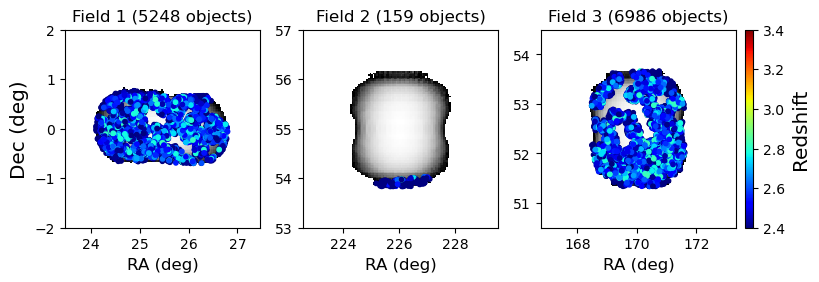

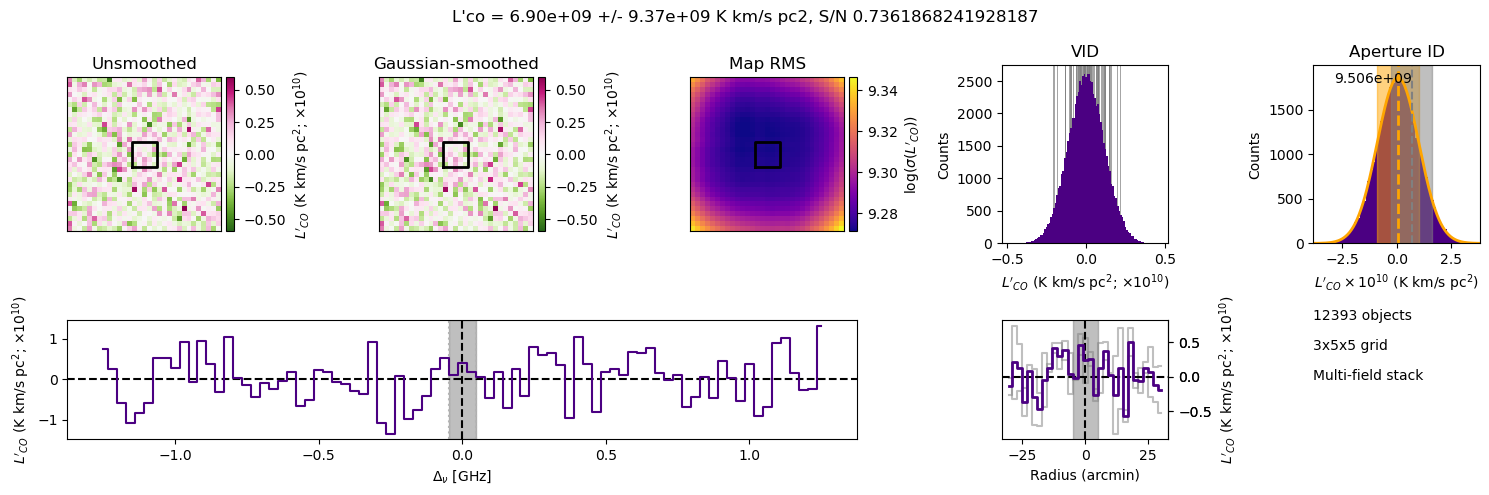

In [41]:
# load in and set up the maps and catalog
params.centfreq = 100.6;
maplist, catlist = st.setup(mapfiles, catfiles, params)
stackcube = st.stacker(maplist, catlist, params)

scaling rms
masking isolated signal pixels
trimming catalog
scaling rms
masking isolated signal pixels


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:2040: RuntimeWarning: Mean of empty slice
  goodidx = np.where(~np.isnan(np.nanmean(mapinst.map, axis=0)))


trimming catalog
scaling rms
masking isolated signal pixels
trimming catalog
Starting field 1
Starting a process with 1451 catalog objectsStarting a process with 1451 catalog objects
Starting a process with 1451 catalog objects

Starting a process with 1451 catalog objects   done 0 of 1451 cutouts in this field

Starting a process with 1455 catalog objects
   done 0 of 1451 cutouts in this field
   done 0 of 1451 cutouts in this field
   done 0 of 1455 cutouts in this field   done 0 of 1451 cutouts in this field



/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/

   done 100 of 1451 cutouts in this field
   done 100 of 1455 cutouts in this field
   done 100 of 1451 cutouts in this field
   done 100 of 1451 cutouts in this field
   done 100 of 1451 cutouts in this field
   done 200 of 1451 cutouts in this field
   done 200 of 1455 cutouts in this field
   done 200 of 1451 cutouts in this field
   done 300 of 1455 cutouts in this field
   done 200 of 1451 cutouts in this field
   done 200 of 1451 cutouts in this field
   done 300 of 1451 cutouts in this field
   done 300 of 1451 cutouts in this field
   done 400 of 1455 cutouts in this field
   done 300 of 1451 cutouts in this field
   done 300 of 1451 cutouts in this field
   done 400 of 1451 cutouts in this field
   done 400 of 1451 cutouts in this field
   done 500 of 1455 cutouts in this field
   done 400 of 1451 cutouts in this field
   done 600 of 1455 cutouts in this field
   done 400 of 1451 cutouts in this field
   done 500 of 1451 cutouts in this field
   done 500 of 1451 cutouts in thi

...

(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
   done 1700 of 1787 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1292: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
Field 3 complete


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1197: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(maplist[i].rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


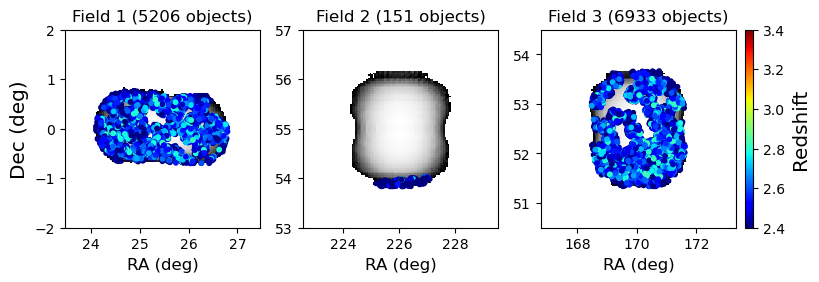

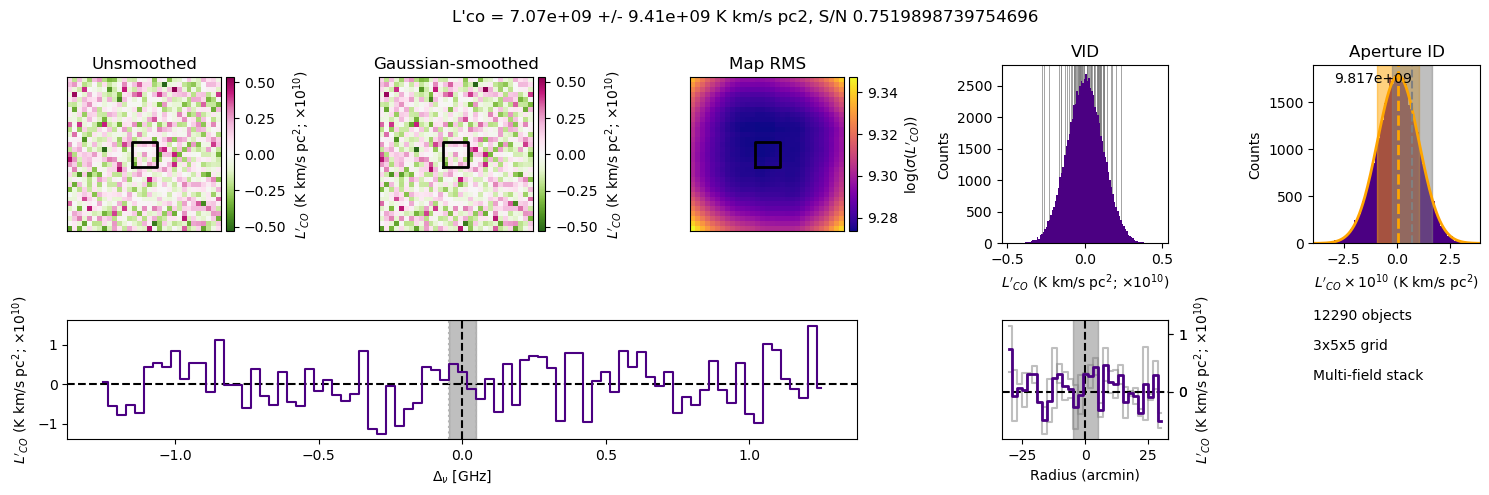

In [42]:
# load in and set up the maps and catalog
params.centfreq = 100.7;
maplist, catlist = st.setup(mapfiles, catfiles, params)
stackcube = st.stacker(maplist, catlist, params)

scaling rms
masking isolated signal pixels
trimming catalog
scaling rms
masking isolated signal pixels


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:2040: RuntimeWarning: Mean of empty slice
  goodidx = np.where(~np.isnan(np.nanmean(mapinst.map, axis=0)))


trimming catalog
scaling rms
masking isolated signal pixels
trimming catalog
Starting field 1
Starting a process with 1446 catalog objects
Starting a process with 1446 catalog objects
Starting a process with 1446 catalog objects
Starting a process with 1446 catalog objects
Starting a process with 1447 catalog objects
   done 0 of 1447 cutouts in this field
   done 0 of 1446 cutouts in this field
   done 0 of 1446 cutouts in this field
   done 0 of 1446 cutouts in this field
   done 0 of 1446 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tool

   done 100 of 1446 cutouts in this field
   done 100 of 1447 cutouts in this field
   done 100 of 1446 cutouts in this field
   done 100 of 1446 cutouts in this field
   done 100 of 1446 cutouts in this field
   done 200 of 1446 cutouts in this field
   done 200 of 1447 cutouts in this field
   done 200 of 1446 cutouts in this field
   done 300 of 1447 cutouts in this field
   done 200 of 1446 cutouts in this field
   done 200 of 1446 cutouts in this field
   done 300 of 1446 cutouts in this field
   done 300 of 1446 cutouts in this field
   done 400 of 1447 cutouts in this field
   done 300 of 1446 cutouts in this field
   done 300 of 1446 cutouts in this field
   done 400 of 1446 cutouts in this field
   done 500 of 1447 cutouts in this field
   done 400 of 1446 cutouts in this field
   done 400 of 1446 cutouts in this field
   done 500 of 1446 cutouts in this field
   done 600 of 1447 cutouts in this field
   done 400 of 1446 cutouts in this field
   done 500 of 1446 cutouts in thi

...

(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
   done 1700 of 1780 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1292: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
Field 3 complete


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1197: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(maplist[i].rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


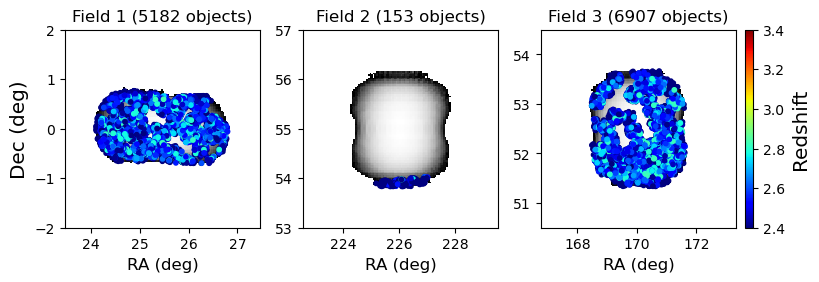

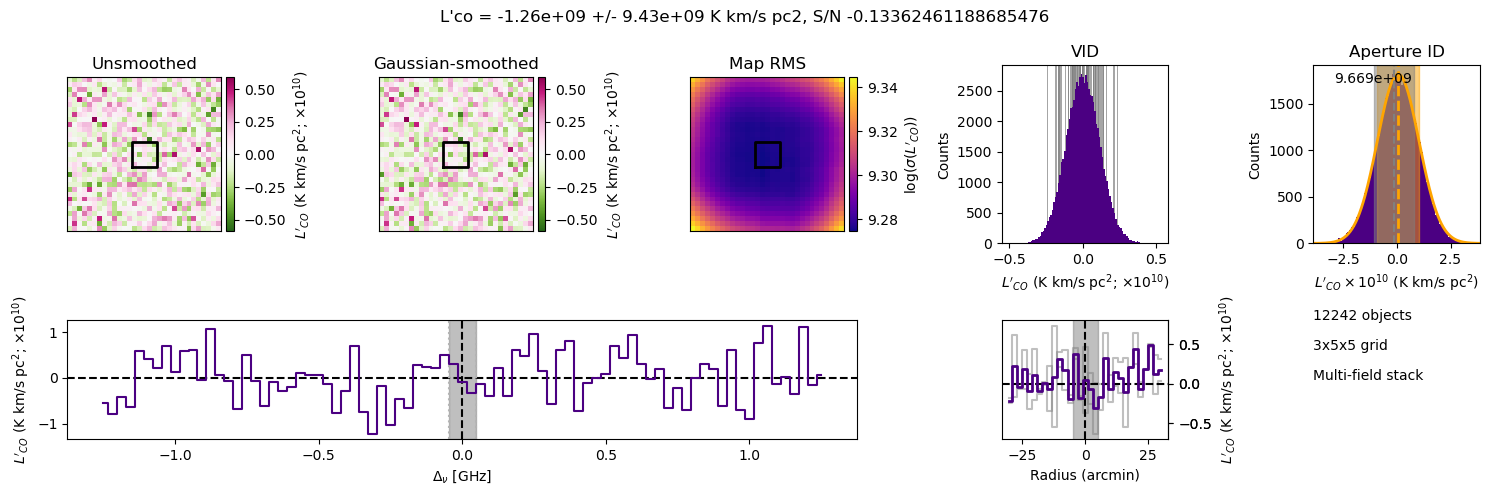

In [43]:
# load in and set up the maps and catalog
params.centfreq = 100.8;
maplist, catlist = st.setup(mapfiles, catfiles, params)
stackcube = st.stacker(maplist, catlist, params)

scaling rms
masking isolated signal pixels
trimming catalog
scaling rms
masking isolated signal pixels


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:2040: RuntimeWarning: Mean of empty slice
  goodidx = np.where(~np.isnan(np.nanmean(mapinst.map, axis=0)))


trimming catalog
scaling rms
masking isolated signal pixels
trimming catalog
Starting field 1
Starting a process with 1439 catalog objects
Starting a process with 1439 catalog objectsStarting a process with 1439 catalog objects

Starting a process with 1439 catalog objects
Starting a process with 1440 catalog objects
   done 0 of 1439 cutouts in this field
   done 0 of 1439 cutouts in this field
   done 0 of 1439 cutouts in this field
   done 0 of 1439 cutouts in this field
   done 0 of 1440 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tool

   done 100 of 1439 cutouts in this field
   done 100 of 1439 cutouts in this field
   done 100 of 1440 cutouts in this field
   done 100 of 1439 cutouts in this field
   done 100 of 1439 cutouts in this field
   done 200 of 1439 cutouts in this field
   done 200 of 1439 cutouts in this field
   done 200 of 1440 cutouts in this field
   done 300 of 1440 cutouts in this field
   done 200 of 1439 cutouts in this field
   done 200 of 1439 cutouts in this field
   done 300 of 1439 cutouts in this field
   done 300 of 1439 cutouts in this field
   done 400 of 1440 cutouts in this field
   done 300 of 1439 cutouts in this field
   done 300 of 1439 cutouts in this field
   done 400 of 1439 cutouts in this field
   done 500 of 1440 cutouts in this field
   done 400 of 1439 cutouts in this field
   done 500 of 1439 cutouts in this field
   done 400 of 1439 cutouts in this field
   done 600 of 1440 cutouts in this field
   done 400 of 1439 cutouts in this field
   done 500 of 1439 cutouts in thi

...

(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
   done 1700 of 1777 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1292: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
Field 3 complete


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1197: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(maplist[i].rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


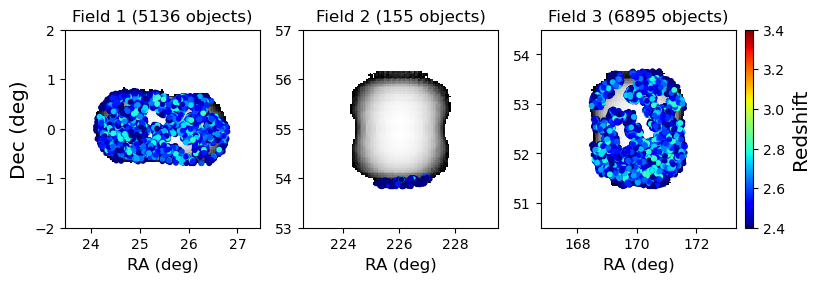

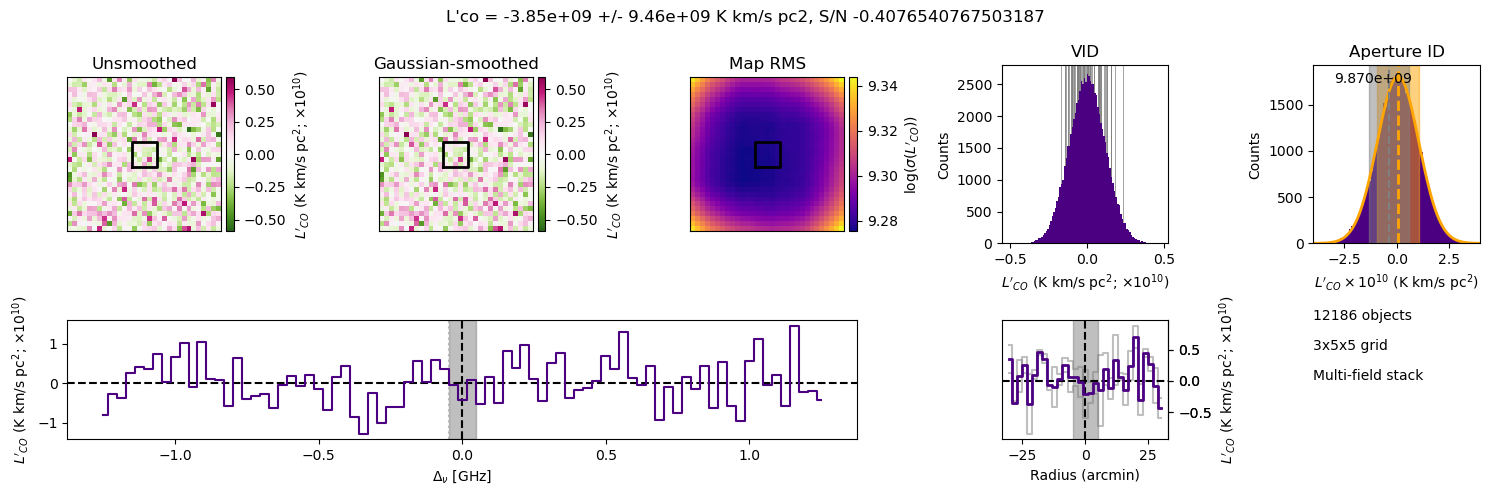

In [44]:
# load in and set up the maps and catalog
params.centfreq = 100.9;
maplist, catlist = st.setup(mapfiles, catfiles, params)
stackcube = st.stacker(maplist, catlist, params)

scaling rms
masking isolated signal pixels
trimming catalog
scaling rms
masking isolated signal pixels


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:2040: RuntimeWarning: Mean of empty slice
  goodidx = np.where(~np.isnan(np.nanmean(mapinst.map, axis=0)))


trimming catalog
scaling rms
masking isolated signal pixels
trimming catalog
Starting field 1
Starting a process with 1436 catalog objects
Starting a process with 1436 catalog objects
Starting a process with 1436 catalog objects
Starting a process with 1436 catalog objects
Starting a process with 1440 catalog objects
   done 0 of 1440 cutouts in this field
   done 0 of 1436 cutouts in this field
   done 0 of 1436 cutouts in this field
   done 0 of 1436 cutouts in this field
   done 0 of 1436 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1836: RuntimeWarning: divide by zero encountered in divide
  meanrms = np.sqrt(1/np.nansum(1*weights, axis=axis))
/home/finneas/Documents/COMAP/stacking/lim_stacker/tools.py:1835: RuntimeWarning: invalid value encountered in divide
  meanval = np.nansum(vals*weights, axis=axis) / np.nansum(1*weights, axis=axis)
/home/finneas/Documents/COMAP/stacking/lim_stacker/tool

   done 100 of 1436 cutouts in this field
   done 100 of 1440 cutouts in this field
   done 100 of 1436 cutouts in this field
   done 100 of 1436 cutouts in this field
   done 100 of 1436 cutouts in this field
   done 200 of 1436 cutouts in this field
   done 200 of 1436 cutouts in this field
   done 200 of 1440 cutouts in this field
   done 300 of 1440 cutouts in this field
   done 200 of 1436 cutouts in this field
   done 200 of 1436 cutouts in this field
   done 300 of 1436 cutouts in this field
   done 300 of 1436 cutouts in this field
   done 400 of 1440 cutouts in this field
   done 300 of 1436 cutouts in this field
   done 300 of 1436 cutouts in this field
   done 400 of 1436 cutouts in this field
   done 500 of 1440 cutouts in this field
   done 400 of 1436 cutouts in this field
   done 400 of 1436 cutouts in this field
   done 500 of 1436 cutouts in this field
   done 600 of 1440 cutouts in this field
   done 400 of 1436 cutouts in this field
   done 500 of 1436 cutouts in thi

...

(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
   done 1700 of 1777 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1292: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
Field 3 complete


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1197: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(maplist[i].rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


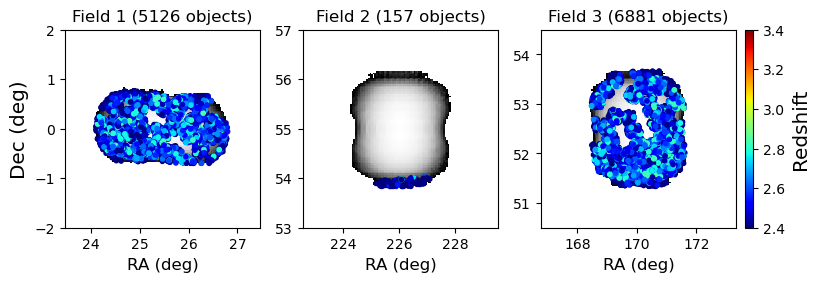

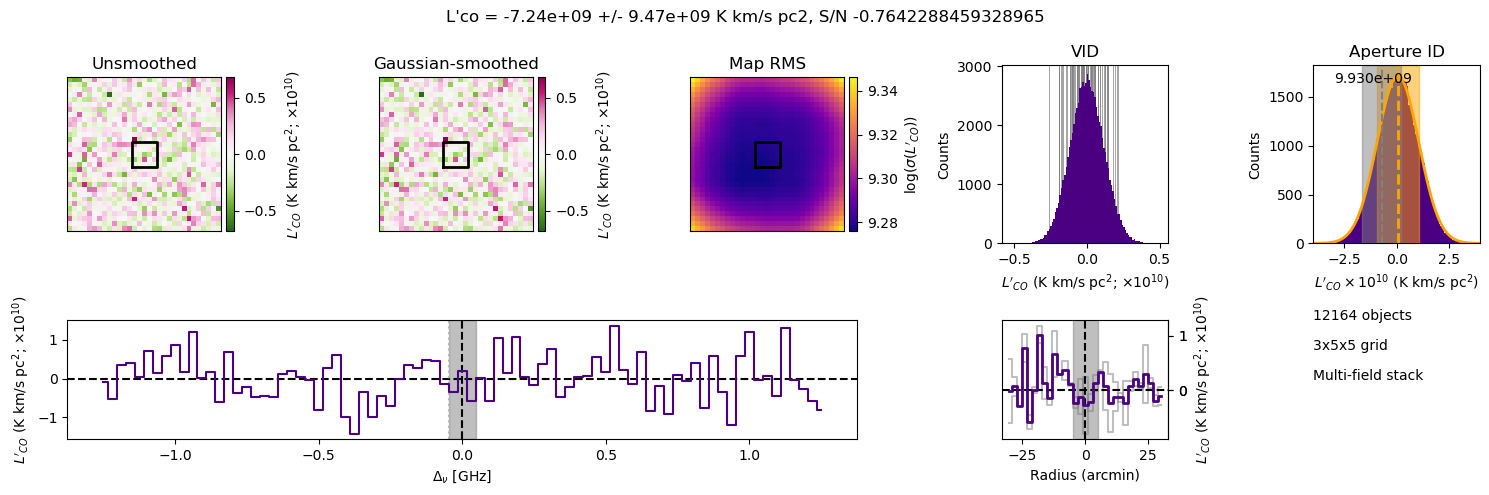

In [45]:
# load in and set up the maps and catalog
params.centfreq = 101;
maplist, catlist = st.setup(mapfiles, catfiles, params)
stackcube = st.stacker(maplist, catlist, params)

In [5]:
print(stackcube.ncutouts)
print(stackcube.linelum)
print(stackcube.dlinelum)

4572
26344433260.22233
11883142583.503149


Starting field 1
Starting a process with 1304 catalog objects
Starting a process with 1304 catalog objects
   done 0 of 1304 cutouts in this fieldStarting a process with 1304 catalog objects

Starting a process with 1304 catalog objects
Starting a process with 1307 catalog objects
   done 0 of 1304 cutouts in this field
   done 0 of 1304 cutouts in this field
   done 0 of 1304 cutouts in this field
   done 0 of 1307 cutouts in this field
   done 100 of 1304 cutouts in this field
   done 100 of 1304 cutouts in this field
   done 100 of 1304 cutouts in this field
   done 100 of 1307 cutouts in this field
   done 100 of 1304 cutouts in this field
   done 200 of 1304 cutouts in this field
   done 200 of 1304 cutouts in this field
   done 200 of 1307 cutouts in this field
   done 200 of 1304 cutouts in this field
   done 300 of 1304 cutouts in this field
   done 200 of 1304 cutouts in this field
   done 300 of 1307 cutouts in this field
   done 300 of 1304 cutouts in this field
   done 400 

/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1242: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
   done 1000 of 1304 cutouts in this field
   done 1100 of 1304 cutouts in this field
   done 1100 of 1304 cutouts in this field
   done 900 of 1304 cutouts in this field
   done 1200 of 1304 cutouts in this field
   done 1200 of 1304 cutouts in this field
   done 1100 of 1304 cutouts in this field
   done 1300 of 1304 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1242: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
   done 1000 of 1304 cutouts in this field
   done 1300 of 1304 cutouts in this field


...

/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1242: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
   done 1500 of 1569 cutouts in this field


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1242: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(comap.rms, axis=0))


(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)
Field 3 complete
(13, 13, 18, 18, 13)
(13, 18, 18, 13, 13)


/home/finneas/Documents/COMAP/stacking/lim_stacker/plottools.py:1147: RuntimeWarning: Mean of empty slice
  logrms = np.log10(np.nanmean(maplist[i].rms, axis=0))


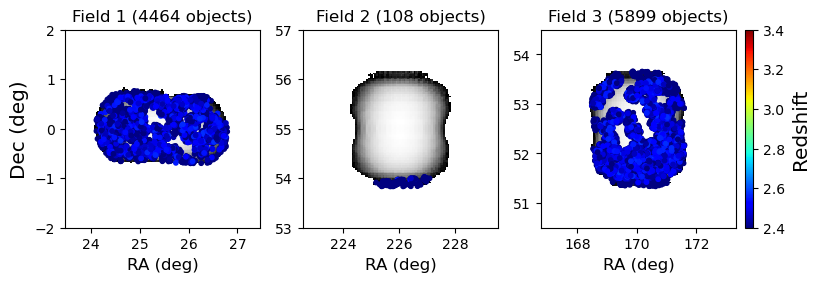

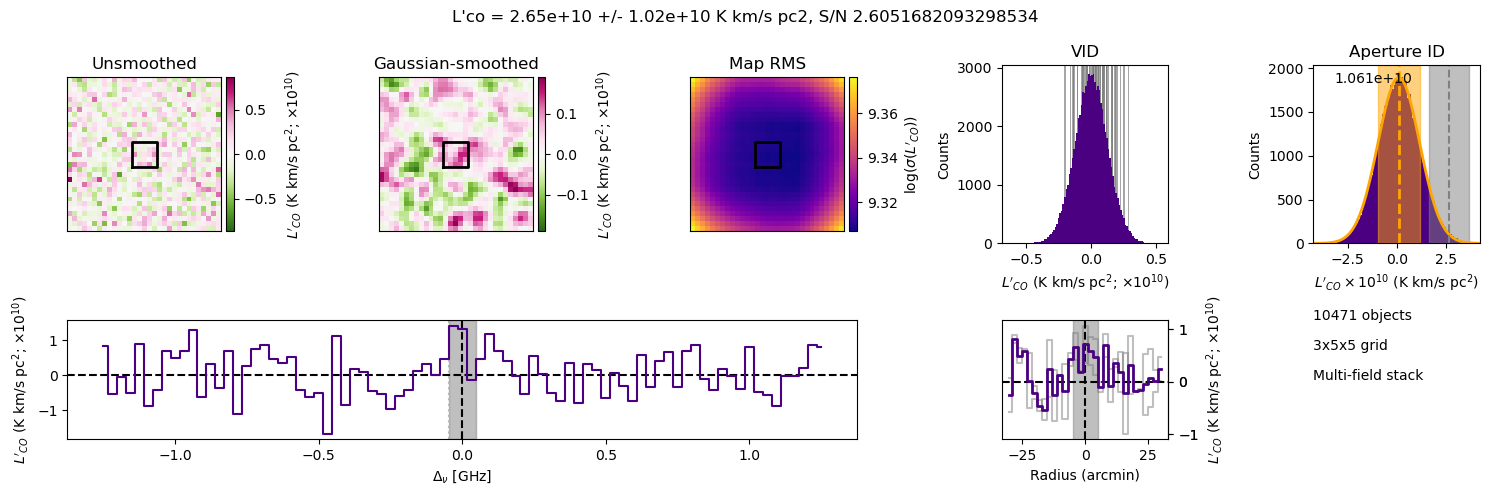

In [16]:
stackcube = st.stacker(maplist, catlist, params)

In [17]:
print(stackcube.ncutouts)
print(stackcube.linelum)
print(stackcube.dlinelum)

10471
26480936895.49089
10164770474.572456


In [ ]:
bogart = np.load('/home/finneas/Documents/COMAP/for_finneas/hetdex_5.0.0_erincuts250421_no_false_positives/z.npy')
bogart

In [4]:
import h5py

In [7]:
h5file = h5py.File(mapfiles[0], 'r')
list(h5file.keys())

['dec_centers',
 'dec_edges',
 'freq_centers',
 'freq_edges',
 'is_highpassed',
 'is_pca_subtr',
 'is_sim',
 'is_simcube',
 'map',
 'map_coadd',
 'map_pca_angvec',
 'map_pca_freqvec',
 'map_saddlebag',
 'n_channels',
 'n_dec',
 'n_pca',
 'n_ra',
 'n_sidebands',
 'nhit',
 'nhit_coadd',
 'nhit_saddlebag',
 'patch_center',
 'pca_approx_noise',
 'ra_centers',
 'ra_edges',
 'sigma_wn',
 'sigma_wn_coadd',
 'sigma_wn_saddlebag']

In [27]:
h5file['dec_edges'][:100]

array([-2.00000000e+00, -1.96666667e+00, -1.93333333e+00, -1.90000000e+00,
       -1.86666667e+00, -1.83333333e+00, -1.80000000e+00, -1.76666667e+00,
       -1.73333333e+00, -1.70000000e+00, -1.66666667e+00, -1.63333333e+00,
       -1.60000000e+00, -1.56666667e+00, -1.53333333e+00, -1.50000000e+00,
       -1.46666667e+00, -1.43333333e+00, -1.40000000e+00, -1.36666667e+00,
       -1.33333333e+00, -1.30000000e+00, -1.26666667e+00, -1.23333333e+00,
       -1.20000000e+00, -1.16666667e+00, -1.13333333e+00, -1.10000000e+00,
       -1.06666667e+00, -1.03333333e+00, -1.00000000e+00, -9.66666667e-01,
       -9.33333333e-01, -9.00000000e-01, -8.66666667e-01, -8.33333333e-01,
       -8.00000000e-01, -7.66666667e-01, -7.33333333e-01, -7.00000000e-01,
       -6.66666667e-01, -6.33333333e-01, -6.00000000e-01, -5.66666667e-01,
       -5.33333333e-01, -5.00000000e-01, -4.66666667e-01, -4.33333333e-01,
       -4.00000000e-01, -3.66666667e-01, -3.33333333e-01, -3.00000000e-01,
       -2.66666667e-01, -

In [118]:
dir(stackcube)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'adaptivephotometry',
 'aperture_vid',
 'apmaxpix',
 'apminpix',
 'beam_model',
 'catidx',
 'centpix',
 'copy',
 'cube',
 'cubefreqwidth',
 'cuberms',
 'cubexwidth',
 'cubeywidth',
 'dlinelum',
 'drhoh2',
 'fieldcatidx',
 'fieldncutouts',
 'freqarr',
 'freqwidth',
 'from_cutout',
 'from_files',
 'fstep',
 'get_aperture',
 'get_image',
 'get_offset_aperture',
 'get_output_dict',
 'get_spectrum',
 'index_by_field',
 'linelum',
 'make_plots',
 'ncutouts',
 'nuobs_mean',
 'pad',
 'padcube',
 'padcuberms',
 'rhoh2',
 'save_cubelet',
 'spectrum',
 

In [22]:
dir(catlist[0])

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'add_false_positives',
 'catfileidx',
 'coords',
 'copy',
 'cull_to_chan',
 'cull_to_map',
 'dec',
 'del_extras',
 'dump',
 'freq',
 'idx',
 'info',
 'load',
 'match_wcs',
 'match_wcs_old',
 'nobj',
 'observation_cull',
 'ra',
 'set_chan',
 'set_nuobs',
 'set_pix',
 'sort',
 'subset',
 'z',
 'z_offset']

In [24]:
catlist[0].coords

<SkyCoord (ICRS): (ra, dec) in deg
    [(24.902647, -2.53000e-04), (24.9057  , -4.58000e-04),
     (24.733826, -4.07870e-02), ..., (26.501179, -5.49120e-02),
     (24.545437,  5.34254e-01), (24.39254 ,  3.61307e-01)]>